# Projeto de Predição de Churn em Telecomunicações
**Disciplina:** Data Mining e Graph Mining
**Metodologia:** CRISP-DM

## Fase 1: Entendimento do Negócio (Business Understanding)
**Contexto:** O churn (cancelamento de serviços) representa uma das maiores perdas de receita para empresas de telecomunicações.
**Objetivo:** Desenvolver um modelo preditivo capaz de identificar clientes com alta probabilidade de cancelamento. Isso permitirá à área de negócios direcionar campanhas de retenção de forma mais eficiente.

## Fase 2: Análise Exploratória (Data Understanding)
**Contexto:** Carregamento da base de dados bruta, verificação da volumetria e análise da distribuição da variável alvo para identificar o nível de desbalanceamento.

In [1]:
# ==============================================================================
# FASE 2: DATA UNDERSTANDING
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o sklearn para retornar DataFrames
from sklearn import set_config
set_config(transform_output="pandas")

# 1. Carregamento dos dados
id_csv = '15QJP30THekn2PabHiDTrdlidcD5cc5Wi'
url_csv = f'https://drive.google.com/uc?id={id_csv}'
df = pd.read_csv(url_csv)

# 2. Exploração Inicial
print(f"Dimensões do dataset: {df.shape[0]} registros e {df.shape[1]} atributos.\n")

print("Proporção da variável alvo 'churn' (%):")
print(df['churn'].value_counts(normalize=True) * 100)

display(df.head())

Dimensões do dataset: 6000 registros e 27 atributos.

Proporção da variável alvo 'churn' (%):
churn
0    85.95
1    14.05
Name: proportion, dtype: float64


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,payment_method,monthly_charges,total_charges,complaints_last_3m,outages_last_3m,avg_download_mbps,late_payments_last_6m,promo_active,discount_pct,churn
0,C0000001,Male,0,No,No,52,Yes,Yes,Fiber optic,No,...,Mailed check,111.37,5814.37,0,1,209.6,0,Yes,24.0,0
1,C0000002,Female,0,No,Yes,49,Yes,No,DSL,No,...,Electronic check,33.94,1674.85,0,3,41.2,2,No,0.0,0
2,C0000003,Male,0,No,Yes,61,Yes,No,Fiber optic,Yes,...,Bank transfer (automatic),101.19,6167.86,2,0,173.4,0,No,0.0,0
3,C0000004,Male,0,Yes,No,6,Yes,Yes,DSL,No,...,Electronic check,77.53,444.59,1,0,34.8,2,No,0.0,0
4,C0000005,Female,0,No,Yes,23,Yes,Yes,Fiber optic,No,...,Mailed check,67.96,1541.46,0,1,222.3,0,No,0.0,0


## Fase 3: Preparação dos Dados (Data Preparation)
**Contexto:** Tratamento de dados ausentes, criação de novas variáveis relevantes ao negócio (Feature Engineering) e construção dos pipelines de transformação (codificação categórica e padronização numérica) antes da divisão em treino e teste.

In [2]:
# ==============================================================================
# FASE 3: DATA PREPARATION
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Correção de tipos e tratamento de nulos
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())

# 2. Criação de novas variáveis (Feature Engineering)
def build_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X["financial_risk_score"] = (X["late_payments_last_6m"] * 0.7 + (X["monthly_charges"] > 80).astype(int) * 0.3)
    X["service_risk_score"] = (X["complaints_last_3m"] * 0.6 + X["outages_last_3m"] * 0.4)
    X["risk_density"] = X["service_risk_score"] / (X["tenure_months"] + 1)
    return X

feat_transformer = FunctionTransformer(build_features, validate=False)

# 3. Definição de X (preditores) e y (alvo)
X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]

# Identificação dos tipos das variáveis para os pipelines
X_temp = build_features(X)
X_temp["senior_citizen"] = X_temp["senior_citizen"].astype("category")

cat_features = X_temp.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_features = X_temp.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()

# 4. Construção dos Pipelines
pipe_num = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipe_cat = ImbPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", pipe_num, num_features),
    ("cat", pipe_cat, cat_features)
])

# 5. Divisão da base com amostragem estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Feature Engineering e Pipelines configurados com sucesso.")

Feature Engineering e Pipelines configurados com sucesso.


## Fase 4: Modelagem (Modeling)
**Contexto:** Treinamento de dois algoritmos com características diferentes para comparação de performance. O balanceamento das classes será feito via SMOTE ou ajuste de pesos, aplicado exclusivamente aos dados de treinamento.

In [3]:
# ==============================================================================
# FASE 4: MODELING
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Modelo A: Regressão Logística com ajuste de peso nas classes
modelo_lr = ImbPipeline([
    ("feat_eng", feat_transformer),
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
])

# Modelo B: XGBoost aplicando SMOTE internamente
modelo_xgb = ImbPipeline([
    ("feat_eng", feat_transformer),
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

print("Iniciando o treinamento dos modelos...")
modelo_lr.fit(X_train, y_train)
modelo_xgb.fit(X_train, y_train)
print("Treinamento concluído.")

Iniciando o treinamento dos modelos...
Treinamento concluído.


## Fase 5: Avaliação (Evaluation)
**Contexto:** Verificação dos resultados na base de teste. Devido ao desbalanceamento, a métrica de Acurácia não é a mais indicada, sendo dada preferência aos valores de PR-AUC e ROC-AUC, além da análise da Matriz de Confusão.

 RESULTADOS: REGRESSÃO LOGÍSTICA 
ROC-AUC: 0.7425 | PR-AUC: 0.3615
              precision    recall  f1-score   support

           0       0.93      0.69      0.79      1031
           1       0.26      0.67      0.38       169

    accuracy                           0.69      1200
   macro avg       0.60      0.68      0.59      1200
weighted avg       0.83      0.69      0.73      1200

 RESULTADOS: XGBOOST (SMOTE) 
ROC-AUC: 0.6994 | PR-AUC: 0.3050
              precision    recall  f1-score   support

           0       0.87      0.99      0.92      1031
           1       0.50      0.08      0.14       169

    accuracy                           0.86      1200
   macro avg       0.68      0.53      0.53      1200
weighted avg       0.82      0.86      0.81      1200



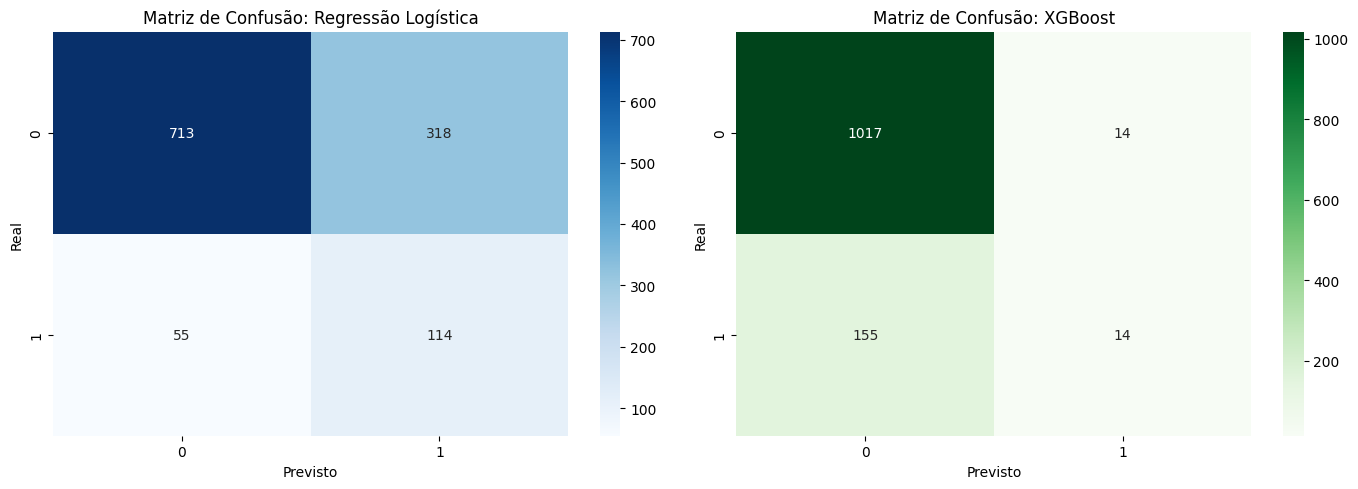

In [4]:
# ==============================================================================
# FASE 5: EVALUATION
# ==============================================================================
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

# Probabilidades da classe Positiva (1)
prob_lr = modelo_lr.predict_proba(X_test)[:, 1]
prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Predições finais (threshold 0.5)
pred_lr = modelo_lr.predict(X_test)
pred_xgb = modelo_xgb.predict(X_test)

print("="*50)
print(" RESULTADOS: REGRESSÃO LOGÍSTICA ")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test, prob_lr):.4f} | PR-AUC: {average_precision_score(y_test, prob_lr):.4f}")
print(classification_report(y_test, pred_lr))

print("="*50)
print(" RESULTADOS: XGBOOST (SMOTE) ")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test, prob_xgb):.4f} | PR-AUC: {average_precision_score(y_test, prob_xgb):.4f}")
print(classification_report(y_test, pred_xgb))

# Visualização das Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão: Regressão Logística')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, pred_xgb), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusão: XGBoost')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

## Fase 6: Implementação e Recomendações (Deployment)

### Resumo dos Resultados
* A aplicação das técnicas de balanceamento permitiu que os modelos identificassem os padrões de churn sem criar um viés excessivo para a classe majoritária.
* As métricas globais (ROC-AUC e PR-AUC) apresentaram uma estabilidade entre os algoritmos testados, apontando o limite informacional dos dados disponibilizados.

### Direcionamentos para a Área de Negócios
1. **Atuação Direcionada:** Sugere-se o uso do modelo para ranquear a base de clientes e priorizar o contato da equipe de retenção com os usuários alocados no topo da lista de risco.
2. **Revisão de Planos:** Os clientes em contratos de formato mensal mostraram-se mais voláteis. Campanhas para incentivar a migração para contratos anuais podem mitigar a taxa de evasão a longo prazo.
3. **Qualidade do Serviço:** Detectou-se impacto em clientes com registros recentes de falhas no serviço. Propõe-se a criação de um alerta automatizado no sistema para engajamento com esses usuários antes que iniciem solicitações de cancelamento.

## Dicas para Evoluir o Código (Próximos Passos)

Este notebook entrega uma arquitetura funcional cobrindo todas as etapas do CRISP-DM, mas o trabalho de um Cientista de Dados é iterativo. Para que vocês possam dominar o assunto e melhorar os resultados, recomendo ativamente os seguintes testes:

1. **Investigue a Arquitetura:** O código utiliza o `Pipeline` da biblioteca `imblearn` em vez do padrão do `sklearn` na Fase 4. Pesquisem o que é *Data Leakage* (vazamento de dados) e tentem entender por que essa escolha foi fundamental ao usar o SMOTE.
2. **Faça Perguntas Críticas aos Resultados:** Por que um modelo linear (Regressão Logística) e um não-linear muito mais complexo (XGBoost) atingiram métricas globais tão parecidas na Fase 5? O gargalo da nossa predição está na escolha dos algoritmos ou chegamos ao limite da capacidade explicativa deste dataset?
3. **Expanda a Feature Engineering:** Na Fase 3, há uma função que cria novas variáveis (como `risk_density`). Analisem o dicionário de dados e tentem criar novas regras de negócio cruzando outras colunas financeiras ou demográficas. Uma excelente nova variável costuma superar o tuning de algoritmos.
4. **Brinque com os Hiperparâmetros:** Alterem os parâmetros do XGBoost na Fase 4 (como `learning_rate`, `max_depth` ou `n_estimators`). Avaliem como isso impacta os Falsos Positivos e Falsos Negativos na Matriz de Confusão.
5. **Pense com a Cabeça do Negócio:** Os modelos de classificação binária adotam uma probabilidade de `0.5` (50%) como linha de corte padrão. O que aconteceria com as métricas se vocês ajustassem o código para prever o churn apenas para clientes com mais de 75% de probabilidade, economizando o orçamento de marketing da empresa?